Датасет: AirPassengers

число пассажиров каждый месяц

Методы:
1) ARIMA
2) Символьная регрессия
3) GMDH MULTI (линейный метод семейства МГУА)
4) GMDH RIA (нелинейный метод семейства МГУА)

In [ ]:
!pip install gplearn

In [ ]:
!pip install gmdh

  Using cached gmdh-1.0.3.tar.gz (14.4 MB)
  Preparing metadata (setup.py) ... done
  Using cached docstring_inheritance-3.0.0-py3-none-any.whl.metadata (10 kB)
Using cached docstring_inheritance-3.0.0-py3-none-any.whl (26 kB)
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for gmdh
  Running setup.py clean for gmdh
Failed to build gmdh
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (gmdh)


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from gplearn.genetic import SymbolicRegressor

try:
    import gmdh
    GMDH_AVAILABLE = True
    print("gmdh успешно импортирован.")
except ModuleNotFoundError:
    GMDH_AVAILABLE = False

# Настройки графиков
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

df = pd.read_csv("AirPassengers.csv")

df.columns = ["Month", "Passengers"]

df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month")

print("Первые строки датасета:")
print(df.head())
print("\nРазмер датасета:", df.shape)

Первые строки датасета:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Размер датасета: (144, 1)


Первичный анализ ряда


Описательная статистика:
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


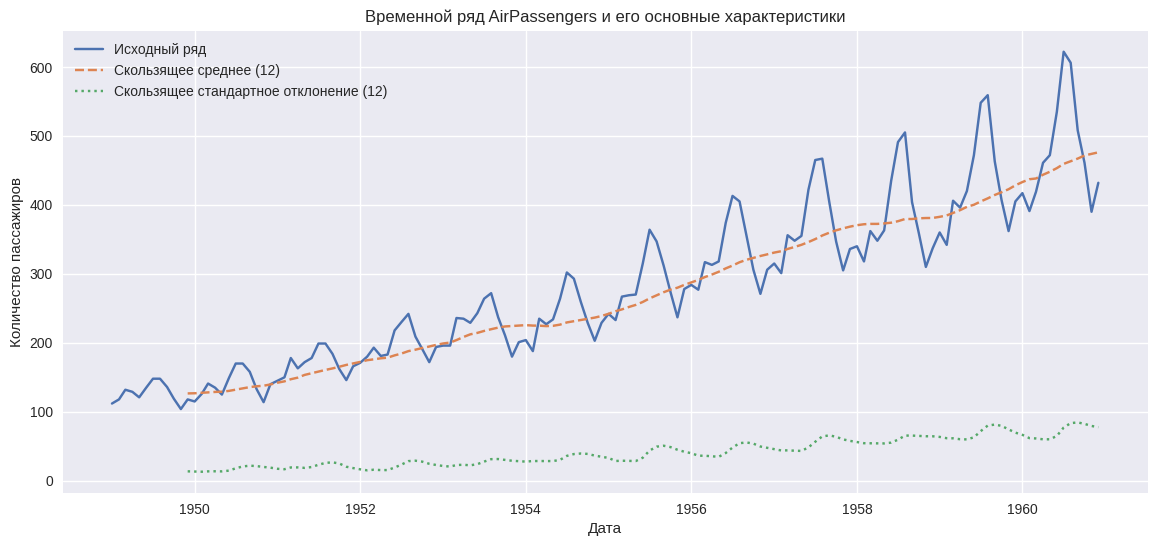

In [ ]:
ts = df["Passengers"]

print("\nОписательная статистика:")
print(ts.describe())

rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(14, 6))
plt.plot(ts, label="Исходный ряд")
plt.plot(rolling_mean, label="Скользящее среднее (12)", linestyle="--")
plt.plot(rolling_std, label="Скользящее стандартное отклонение (12)", linestyle=":")
plt.title("Временной ряд AirPassengers и его основные характеристики")
plt.xlabel("Дата")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.grid(True)
plt.show()

Декомпозиция ряда

Тренд – плавная линия долгосрочного роста или падения уровня ряда. Здесь видно устойчивый рост числа пассажиров со временем.

Сезонность – регулярные годовые колебания (пики по месяцам), которые повторяются из года в год.

Остаток – случайные колебания, которые не объясняются трендом и сезонностью.

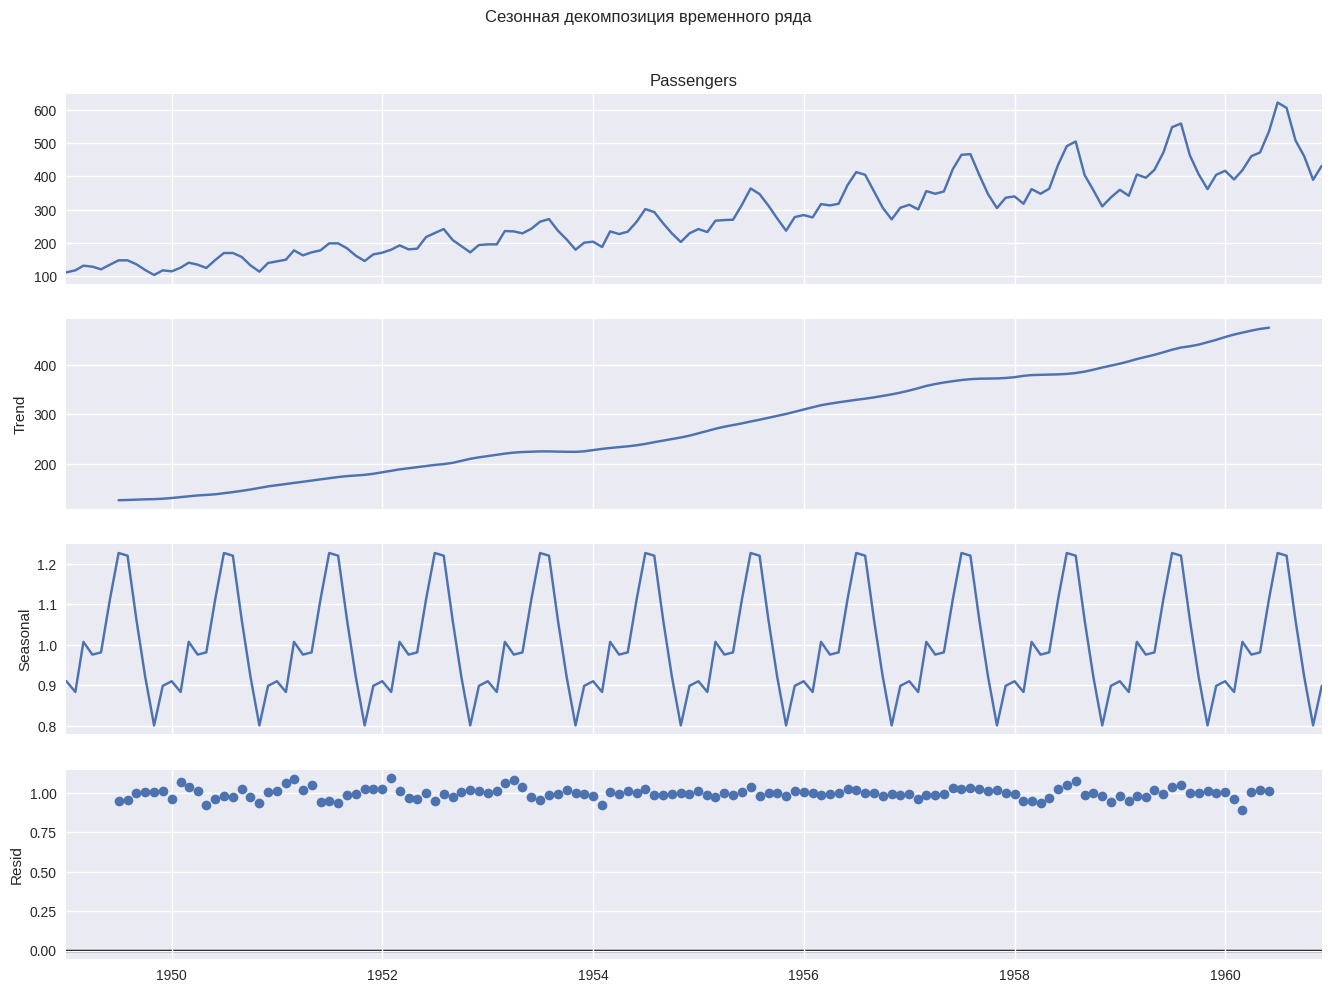

In [ ]:
decomposition = seasonal_decompose(ts, model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Сезонная декомпозиция временного ряда", y=1.02)
plt.show()

Проверка стационарности

Стационарный ряд – ряд, у которого среднее, дисперсия и структура автокорреляций не меняются во времени.

Почему это важно:

Классические модели типа ARIMA предполагают стационарность входных данных.

Если ряд нестационарен (есть тренд, меняющаяся дисперсия), оценки параметров будут нестабильными, а прогноз – хуже.

График показывает ряд после логарифмирования и первого дифференцирования. В таком виде тренд и рост амплитуды сезонности в значительной степени убраны, колебания становятся более однородными, и ADF‑тест подтверждает стационарность. Именно с таким преобразованным рядом удобно работать в ARIMA


ADF-тест: исходный ряд
ADF statistic: 0.8153688792060498
p-value: 0.991880243437641
lags used: 13
nobs: 130
Вывод: ряд нестационарен

ADF-тест: логарифм ряда
ADF statistic: -1.7170170891069683
p-value: 0.4223667747703874
lags used: 13
nobs: 130
Вывод: ряд нестационарен

ADF-тест: логарифм + первое дифференцирование
ADF statistic: -2.717130598388114
p-value: 0.07112054815086184
lags used: 14
nobs: 128
Вывод: ряд нестационарен


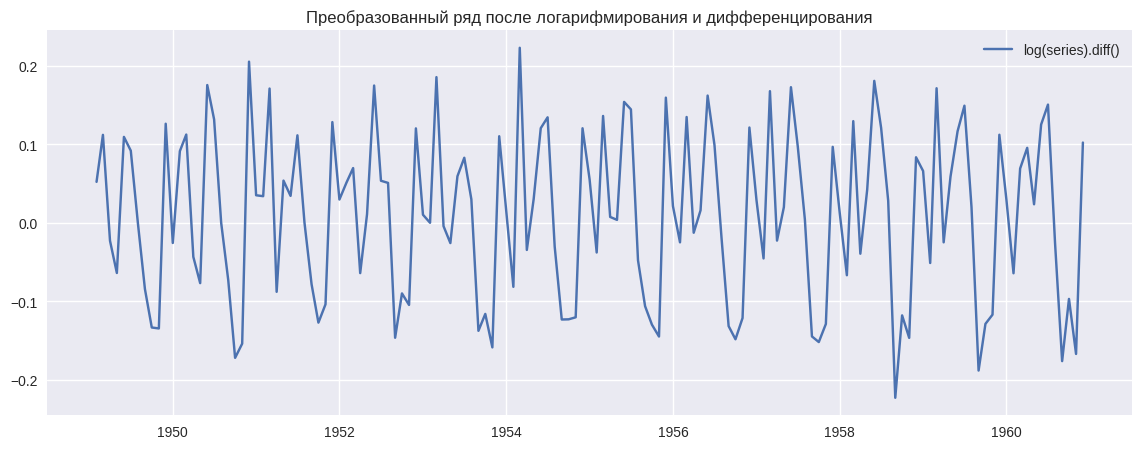

In [ ]:
def adf_test(series, title=""):
    print(f"\nADF-тест: {title}")
    result = adfuller(series.dropna())
    labels = ["ADF statistic", "p-value", "lags used", "nobs"]
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    if result[1] < 0.05:
        print("Вывод: ряд стационарен")
    else:
        print("Вывод: ряд нестационарен")

adf_test(ts, "исходный ряд")

ts_log = np.log(ts)
adf_test(ts_log, "логарифм ряда")

ts_log_diff = ts_log.diff().dropna()
adf_test(ts_log_diff, "логарифм + первое дифференцирование")

plt.figure(figsize=(14, 5))
plt.plot(ts_log_diff, label="log(series).diff()")
plt.title("Преобразованный ряд после логарифмирования и дифференцирования")
plt.legend()
plt.grid(True)
plt.show()

Разделение на train/test


Обучающая выборка: 120
Тестовая выборка: 24


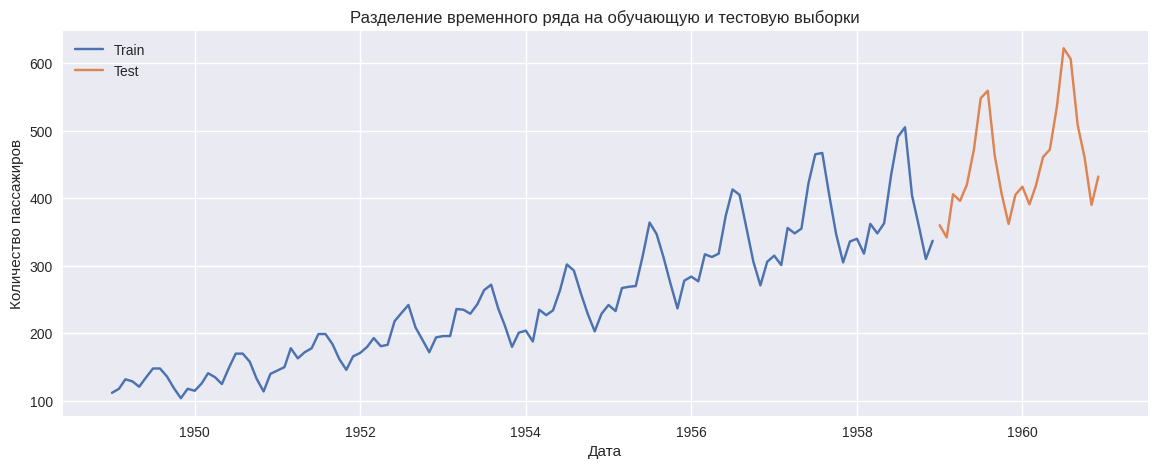

In [ ]:
test_size = 24  # последние 24 месяца
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("\nОбучающая выборка:", train.shape[0])
print("Тестовая выборка:", test.shape[0])

plt.figure(figsize=(14, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Разделение временного ряда на обучающую и тестовую выборки")
plt.xlabel("Дата")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.grid(True)
plt.show()

Метрики качества

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred)
    }

ARIMA

Для AirPassengers часто хорошо работает ARIMA после логарифмирования.
Здесь берем классическую конфигурацию (2,1,2)

In [ ]:
arima_model = ARIMA(np.log(train), order=(2, 1, 2))
arima_fitted = arima_model.fit()

arima_forecast_log = arima_fitted.forecast(steps=len(test))
arima_forecast = np.exp(arima_forecast_log)
arima_forecast.index = test.index

print("\nARIMA summary:")
print(arima_fitted.summary())


ARIMA summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 107.730
Date:                Fri, 22 May 2026   AIC                           -205.461
Time:                        12:35:48   BIC                           -191.565
Sample:                    01-01-1949   HQIC                          -199.818
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2556      0.191      1.336      0.181      -0.119       0.630
ar.L2          0.2383      0.237      1.006      0.314      -0.226       0.702
ma.L1         -0.1103      0.142    

Символьная регрессия

Символьная регрессия – это метод, который не просто подбирает коэффициенты, а ищет явное аналитическое выражение (формулу), которая лучше всего описывает зависимость между признаками и целевой переменной

Символьная регрессия не работает напрямую с датой,
поэтому строим признаки:
- номер времени
- sin/cos сезонности с периодом 12
- лаги 1, 2, 12

In [ ]:
sr_df = df.copy()
sr_df["t"] = np.arange(len(sr_df))
sr_df["month_num"] = sr_df.index.month
sr_df["sin12"] = np.sin(2 * np.pi * sr_df["month_num"] / 12)
sr_df["cos12"] = np.cos(2 * np.pi * sr_df["month_num"] / 12)
sr_df["lag1"] = sr_df["Passengers"].shift(1)
sr_df["lag2"] = sr_df["Passengers"].shift(2)
sr_df["lag12"] = sr_df["Passengers"].shift(12)

sr_df = sr_df.dropna()

sr_train = sr_df.iloc[:-test_size]
sr_test = sr_df.iloc[-test_size:]

X_train_sr = sr_train[["t", "sin12", "cos12", "lag1", "lag2", "lag12"]]
y_train_sr = sr_train["Passengers"]
X_test_sr = sr_test[["t", "sin12", "cos12", "lag1", "lag2", "lag12"]]
y_test_sr = sr_test["Passengers"]

sym_model = SymbolicRegressor(
    population_size=2000,
    generations=20,
    tournament_size=20,
    stopping_criteria=0.01,
    const_range=(-5, 5),
    init_depth=(2, 5),
    function_set=("add", "sub", "mul", "div"),
    metric="mse",
    parsimony_coefficient=0.001,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42
)

sym_model.fit(X_train_sr, y_train_sr)
sym_forecast = sym_model.predict(X_test_sr)
sym_forecast = pd.Series(sym_forecast, index=y_test_sr.index)

print("\nЛучшая формула символьной регрессии:")
print(sym_model._program)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    17.89      2.04205e+42        7          784.953          1929.48      1.47m
   1     8.07      8.87122e+16       15          744.855          2350.76     27.82s
   2     5.78      5.21782e+15        9          625.046          796.433     28.00s
   3     6.10      3.33814e+12        9          514.347          402.903     23.83s
   4     6.77      2.90483e+18       13          310.706          299.052     23.26s
   5     8.67       6.0051e+11       21          248.396          313.274     27.06s
   6    13.74      4.43451e+11       23          220.124          461.262     39.32s
   7    18.45      2.78408e+16       21          221.201          470.313     21.86s
   8    19.56      1.08322e+13       23          215.206          504.625  

Подготовка данных для GMDH

GMDH работает с лагами ряда


In [ ]:
results = []

results.append(evaluate_model("ARIMA", test, arima_forecast))
results.append(evaluate_model("Symbolic Regression", y_test_sr, sym_forecast))

if GMDH_AVAILABLE:

    lags = 12
    series_values = ts.values.astype(float)
    X_gmdh, y_gmdh = gmdh.time_series_transformation(series_values, lags=lags)

    train_len_gmdh = len(X_gmdh) - test_size

    X_train_gmdh = X_gmdh[:train_len_gmdh]
    X_test_gmdh = X_gmdh[train_len_gmdh:]
    y_train_gmdh = y_gmdh[:train_len_gmdh]
    y_test_gmdh = y_gmdh[train_len_gmdh:]

    gmdh_test_index = ts.index[-test_size:]

    # GMDH MULTI
    multi_model = gmdh.Multi()
    multi_model.fit(
        X_train_gmdh,
        y_train_gmdh,
        criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY),
        k_best=3,
        test_size=0.3,
        p_average=1,
        n_jobs=1,
        verbose=0,
        limit=0
    )

    multi_forecast = multi_model.predict(X_test_gmdh)
    multi_forecast = pd.Series(multi_forecast, index=gmdh_test_index)

    print("\nЛучший полином MULTI:")
    print(multi_model.get_best_polynomial())

    # GMDH RIA
    ria_model = gmdh.Ria()
    ria_model.fit(
        X_train_gmdh,
        y_train_gmdh,
        criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY),
        k_best=3,
        polynomial_type=gmdh.PolynomialType.QUADRATIC,
        test_size=0.3,
        p_average=1,
        n_jobs=1,
        verbose=0,
        limit=0
    )

    ria_forecast = ria_model.predict(X_test_gmdh)
    ria_forecast = pd.Series(ria_forecast, index=gmdh_test_index)

    print("\nЛучший полином RIA:")
    print(ria_model.get_best_polynomial())

    # Метрики для GMDH
    results.append(evaluate_model("GMDH MULTI", y_test_gmdh, multi_forecast.values))
    results.append(evaluate_model("GMDH RIA", y_test_gmdh, ria_forecast.values))
else:
    print("\nGMDH недоступен, пропускаем MULTI и RIA.")
    multi_forecast = None
    ria_forecast = None


GMDH недоступен, пропускаем MULTI и RIA.


In [ ]:
results_df = pd.DataFrame(results)
print("\nСравнение моделей:")
print(results_df.sort_values("RMSE"))


Сравнение моделей:
                 Model        MAE        RMSE   MAPE (%)
1  Symbolic Regression  18.912233   22.092279   4.192084
0                ARIMA  87.555764  112.660988  17.481187


Визуализация прогнозов

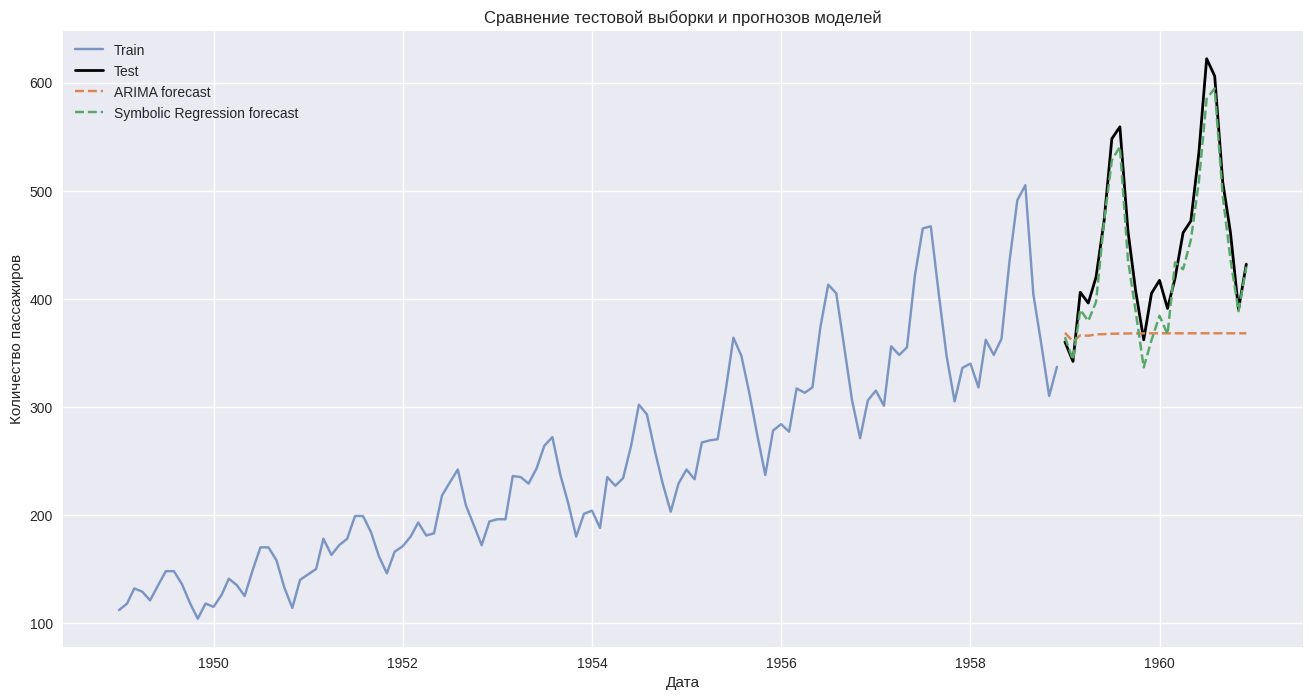

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(train, label="Train", alpha=0.7)
plt.plot(test, label="Test", color="black", linewidth=2)
plt.plot(arima_forecast, label="ARIMA forecast", linestyle="--")
plt.plot(sym_forecast, label="Symbolic Regression forecast", linestyle="--")

if GMDH_AVAILABLE:
    plt.plot(multi_forecast, label="GMDH MULTI forecast", linestyle="--")
    plt.plot(ria_forecast, label="GMDH RIA forecast", linestyle="--")

plt.title("Сравнение тестовой выборки и прогнозов моделей")
plt.xlabel("Дата")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.grid(True)
plt.show()

 Отдельные графики по моделям

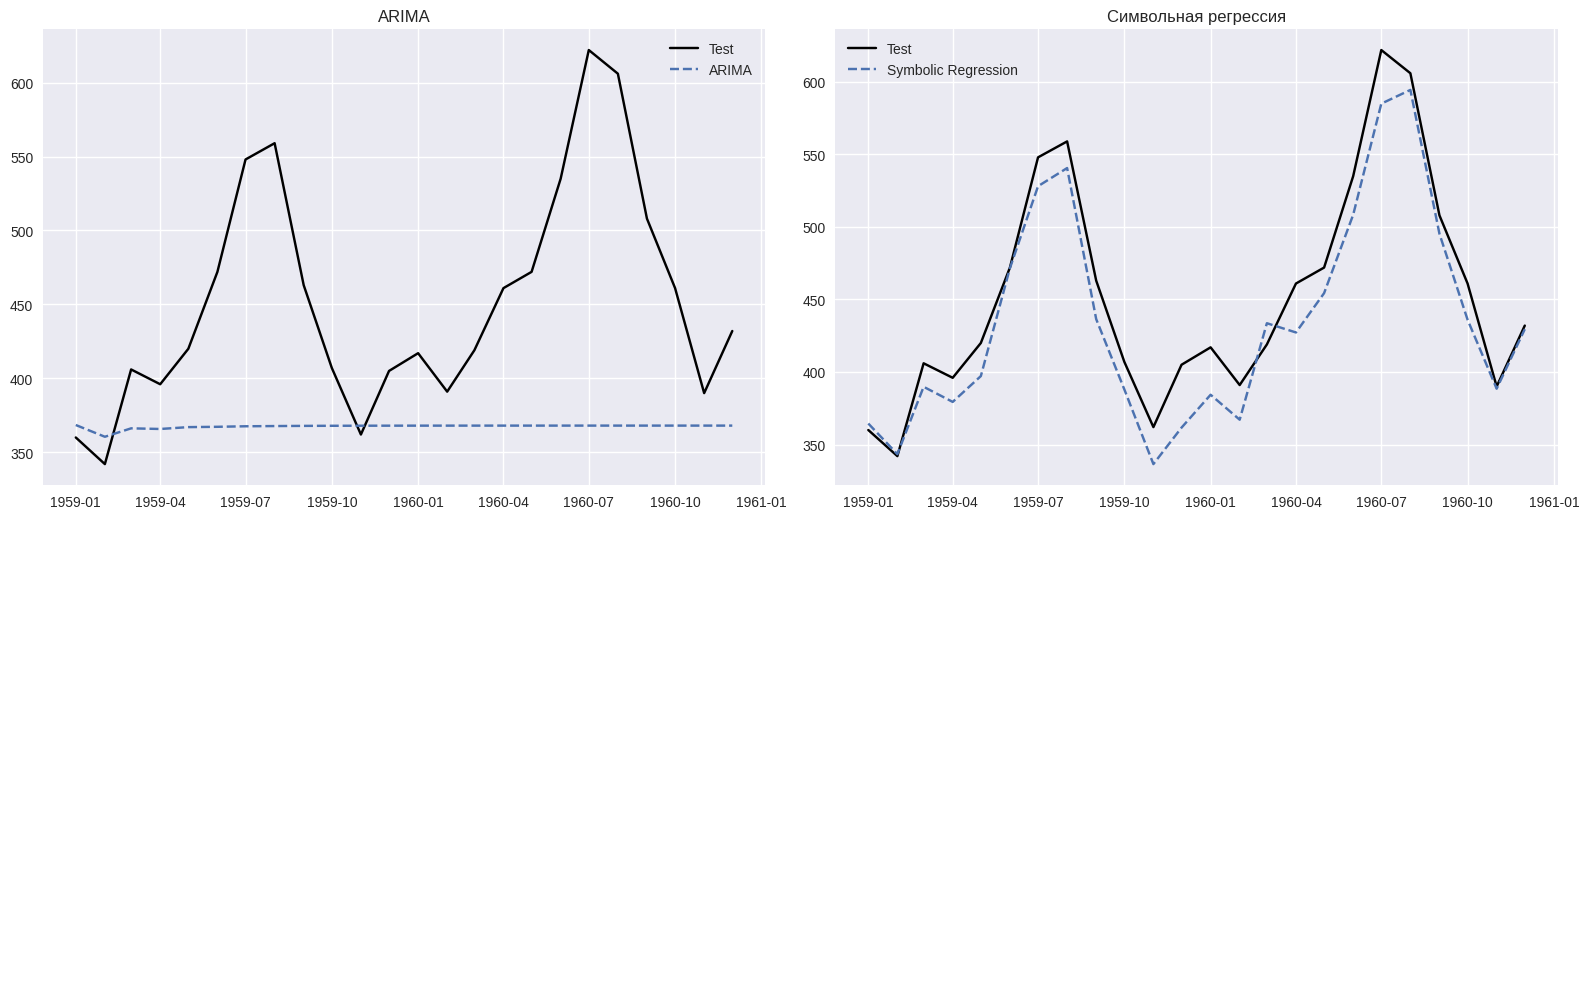

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(test, label="Test", color="black")
axes[0, 0].plot(arima_forecast, label="ARIMA", linestyle="--")
axes[0, 0].set_title("ARIMA")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(y_test_sr, label="Test", color="black")
axes[0, 1].plot(sym_forecast, label="Symbolic Regression", linestyle="--")
axes[0, 1].set_title("Символьная регрессия")
axes[0, 1].legend()
axes[0, 1].grid(True)

if GMDH_AVAILABLE:
    axes[1, 0].plot(pd.Series(y_test_gmdh, index=gmdh_test_index),
                    label="Test", color="black")
    axes[1, 0].plot(multi_forecast, label="GMDH MULTI", linestyle="--")
    axes[1, 0].set_title("GMDH MULTI")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(pd.Series(y_test_gmdh, index=gmdh_test_index),
                    label="Test", color="black")
    axes[1, 1].plot(ria_forecast, label="GMDH RIA", linestyle="--")
    axes[1, 1].set_title("GMDH RIA")
    axes[1, 1].legend()
    axes[1, 1].grid(True)
else:
    axes[1, 0].axis("off")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()